In [11]:
import numpy as np
import dpluspy
import matplotlib.pyplot as plt 
import matplotlib 
from matplotlib.transforms import ScaledTranslation
import msprime
import demes
import moments
import pickle


matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = \
    r"\usepackage{amsmath}\usepackage{amssymb}"
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.serif"] = "Computer Modern"
matplotlib.rcParams["savefig.bbox"] = "tight"
matplotlib.rcParams["axes.linewidth"] = 0.5
matplotlib.rcParams["font.size"] = 9
matplotlib.rcParams['xtick.labelsize'] = 7
matplotlib.rcParams['ytick.labelsize'] = 7
matplotlib.rcParams['ytick.major.size'] = 2
lw = 1

In [12]:
data = {}
for ii in range(1, 23):
    fname = f"../data/statistics/main/raw_sums/sums_Bherer_weighted_chr_{ii}.pkl"
    with open(fname, "rb") as fin:
        data.update(pickle.load(fin))
for x in data:
    data[x]["sums"] = data[x]["sums"][[-1]]
    data[x]["denoms"] = data[x]["denoms"][[-1]]
    data[x].pop("bins")

pop_ids_all = data[next(iter(data))]["pop_ids"]
pop_ids = pop_ids_all[:8]

graph_file = "../models/full_model/round_6/fitted_models/full_model_round_6_Bherer_fit_13.yaml"
model = dpluspy.inference.compute_bin_stats(
    graph_file, u=1.3e-8, sampled_demes=pop_ids, bins=np.array([0, 0.1]))

In [ ]:
# bootstrap over heterozygosities

pi_sums_all = [data[x]["sums"][0] for x in data]
pi_sums = np.array(dpluspy.bootstrapping.subset_means(
    pi_sums_all, pop_ids=pop_ids_all, to_pops=pop_ids))
pi_denoms = np.array([data[x]["denoms"][0] for x in data])
pi_samples = np.array(dpluspy.bootstrapping.get_bootstrap_reps(data))[:, 0]

def separate_stats(stats, pop_ids):
    # seperate out one/two-population stats.
    num_pops = len(pop_ids)
    one_pop = np.zeros(num_pops)
    two_pop = np.zeros(int(num_pops * (num_pops - 1) / 2))
    tally = 0
    for ii in range(num_pops):
        for jj in range(ii, num_pops):
            if ii == jj:
                one_pop[ii] = stats[tally]
            else:
                two_pop[tally - ii - 1] = stats[tally]
            tally += 1
    return one_pop, two_pop

pi_means = pi_sums.sum(0) / pi_denoms.sum(0)
pi_stds = np.var(pi_samples, axis=0) ** 0.5
H_means, div_means = separate_stats(pi_means, pop_ids)
H_stds, div_stds = separate_stats(pi_stds, pop_ids)
H_exp, div_exp = separate_stats(model[-1], pop_ids)

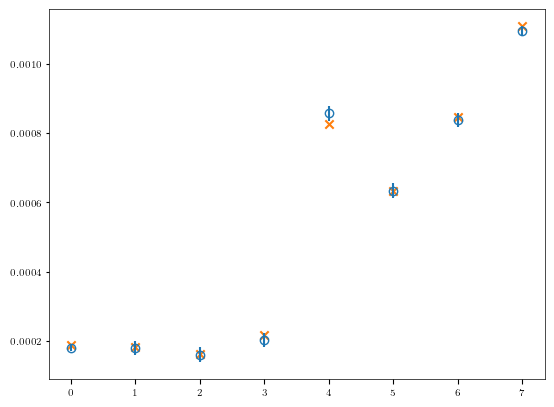

In [15]:
plt.errorbar(range(8), H_means, yerr=H_stds * 1.96, linestyle="none",
             marker="o", mfc="none")
plt.scatter(range(8), H_exp, color="tab:orange", marker="x")

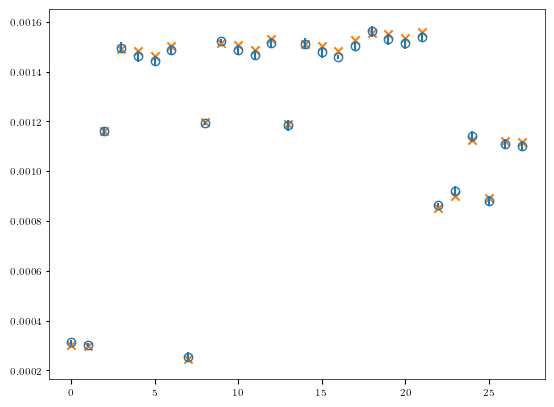

In [16]:
plt.errorbar(range(len(div_means)), div_means, yerr=div_stds * 1.96, linestyle="none",
             marker="o", mfc="none")
plt.scatter(range(len(div_means)), div_exp, color="tab:orange", marker="x")

In [ ]:
# prepare some objects for plotting

mean_matrix = np.zeros((8, 8))
std_matrix = np.zeros((8, 8))
exp_matrix = np.zeros((8, 8))
tally = 0
for ii in range(8):
    mean_matrix[ii, ii] = H_means[ii]
    std_matrix[ii, ii] = H_stds[ii]
    exp_matrix[ii, ii] = H_exp[ii]
    for jj in range(ii + 1, 8):
        mean_matrix[jj, ii] = div_means[tally]
        std_matrix[jj, ii] = div_stds[tally]
        exp_matrix[jj, ii] = div_exp[tally]
        mean_matrix[ii, jj] = std_matrix[ii, jj] = exp_matrix[ii, jj] = np.nan
        tally += 1
pi_res = (exp_matrix - mean_matrix) / std_matrix


def compute_f2(stats, pop_ids):
    num_pops = len(pop_ids)
    matrix = np.full((num_pops, num_pops), np.nan)
    stat_names = dpluspy.utils._H_names(list(range(num_pops)))
    for ii in range(num_pops):
        matrix[ii, ii] = np.nan
        for jj in range(ii + 1, num_pops):
            H_X = stats[stat_names.index(f"H_{ii}_{ii}")]
            H_Y = stats[stat_names.index(f"H_{jj}_{jj}")]
            H_XY = stats[stat_names.index(f"H_{ii}_{jj}")]
            matrix[jj, ii] = H_XY - (H_X + H_Y) / 2
    return matrix


f2_exp = model.F2_matrix()
for ii in range(len(pop_ids)):
    f2_exp[ii, ii:] = np.nan
f2_mean = compute_f2(pi_means, pop_ids)
f2_samples = np.array([compute_f2(samp, pop_ids) for samp in pi_samples])
f2_var = np.var(f2_samples, axis=0)
f2_res = (f2_exp - f2_mean) / f2_var ** 0.5

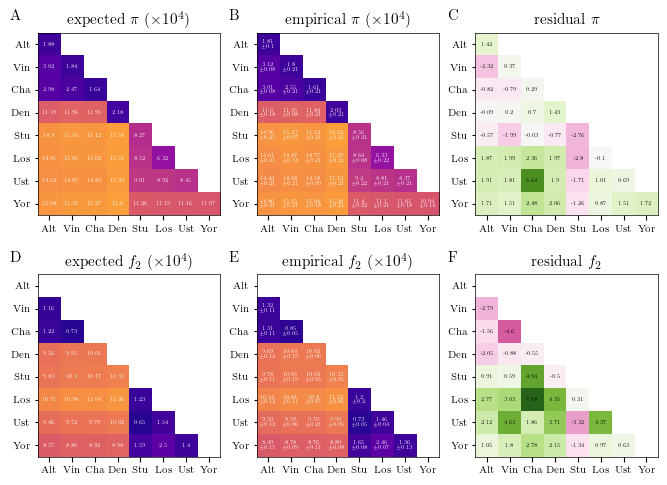

In [19]:
mosaic = "ABC;DEF"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 5.75))

# diversity statistics
axs["A"].imshow(exp_matrix, vmin=0, vmax=0.002, cmap="plasma")
axs["B"].imshow(mean_matrix, vmin=0, vmax=0.002, cmap="plasma")
axs["C"].imshow(pi_res, vmin=-7, vmax=7, cmap="PiYG")

for ii in range(8):
    for jj in range(ii, 8):
        x = np.round(mean_matrix[jj, ii] * 1e4, 2)
        ci = np.round(std_matrix[jj, ii] * 1e4 * 1.96, 2)
        txt = f"{x}\n $\\pm${ci}"
        axs["B"].text(ii, jj, txt, ha="center", va="center", color="white", size=3.5)

        x = np.round(exp_matrix[jj, ii] * 1e4, 2)
        axs["A"].text(ii, jj, x, ha="center", va="center", color="white", size=3.5)

        x = np.round(pi_res[jj, ii], 2)
        axs["C"].text(ii, jj, x, ha="center", va="center", color="black", size=3.5)

for label in axs:
    axs[label].set_xticks(range(8), [x[:3] for x in pop_ids])
    axs[label].set_yticks(range(8), [x[:3] for x in pop_ids])


# f2 statistics
axs["D"].imshow(f2_exp, vmin=0, vmax=0.0015, cmap="plasma")
axs["E"].imshow(f2_mean, vmin=0, vmax=0.0015, cmap="plasma")
axs["F"].imshow(f2_res, cmap="PiYG", vmin=-7, vmax=7)

for ii in range(8):
    for jj in range(ii + 1, 8):
        x = np.round(f2_mean[jj, ii] * 1e4, 2)
        ci = np.round(f2_var[jj, ii] ** 0.5 * 1.96 * 1e4, 2)
        txt = f"{x}\n $\\pm${ci}"
        axs["E"].text(ii, jj, txt, ha="center", va="center", color="white", size=3.5)

        x = np.round(f2_exp[jj, ii] * 1e4, 2)
        axs["D"].text(ii, jj, x, ha="center", va="center", color="white", size=3.5)

        x = np.round(f2_res[jj, ii], 2)
        axs["F"].text(ii, jj, x, ha="center", va="center", color="black", size=3.5)

for label, ax in axs.items():
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)))

axs["A"].set_title(r"expected $\pi$ ($\times 10^4$)")
axs["B"].set_title(r"empirical $\pi$ ($\times 10^4$)")
axs["C"].set_title(r"residual $\pi$")

axs["D"].set_title(r"expected $f_2$ ($\times 10^4$)")
axs["E"].set_title(r"empirical $f_2$ ($\times 10^4$)")
axs["F"].set_title(r"residual $f_2$")

plt.savefig("figures/figS_diversity_predictions.pdf")

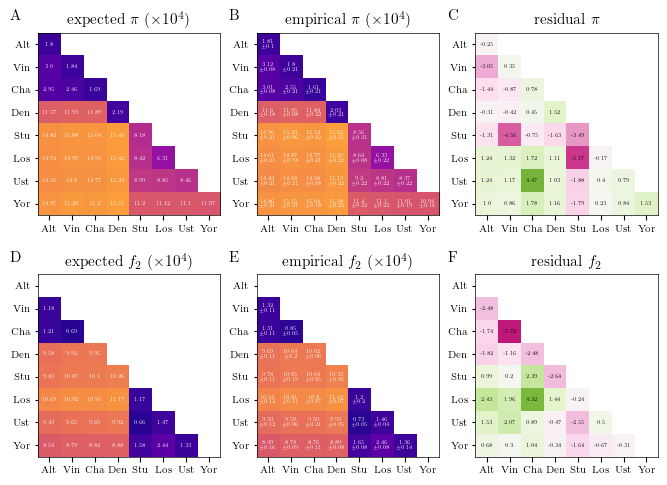

In [21]:
data = {}
for ii in range(1, 23):
    fname = f"../data/statistics/main/raw_sums/sums_ZhouJHS_weighted_chr_{ii}.pkl"
    with open(fname, "rb") as fin:
        data.update(pickle.load(fin))
for x in data:
    data[x]["sums"] = data[x]["sums"][[-1]]
    data[x]["denoms"] = data[x]["denoms"][[-1]]
    data[x].pop("bins")

pop_ids_all = data[next(iter(data))]["pop_ids"]
pop_ids = pop_ids_all[:8]

graph_file = "../models/full_model/round_6/fitted_models/full_model_round_6_ZhouJHS_fit_47.yaml"
model = dpluspy.inference.compute_bin_stats(
    graph_file, u=1.3e-8, sampled_demes=pop_ids, bins=np.array([0, 0.1]))

# bootstrap over heterozygosities

pi_sums_all = [data[x]["sums"][0] for x in data]
pi_sums = np.array(dpluspy.bootstrapping.subset_means(
    pi_sums_all, pop_ids=pop_ids_all, to_pops=pop_ids))
pi_denoms = np.array([data[x]["denoms"][0] for x in data])
pi_samples = np.array(dpluspy.bootstrapping.get_bootstrap_reps(data))[:, 0]

def separate_stats(stats, pop_ids):
    # seperate out one/two-population stats.
    num_pops = len(pop_ids)
    one_pop = np.zeros(num_pops)
    two_pop = np.zeros(int(num_pops * (num_pops - 1) / 2))
    tally = 0
    for ii in range(num_pops):
        for jj in range(ii, num_pops):
            if ii == jj:
                one_pop[ii] = stats[tally]
            else:
                two_pop[tally - ii - 1] = stats[tally]
            tally += 1
    return one_pop, two_pop

pi_means = pi_sums.sum(0) / pi_denoms.sum(0)
pi_stds = np.var(pi_samples, axis=0) ** 0.5
H_means, div_means = separate_stats(pi_means, pop_ids)
H_stds, div_stds = separate_stats(pi_stds, pop_ids)
H_exp, div_exp = separate_stats(model[-1], pop_ids)


# prepare some objects for plotting

mean_matrix = np.zeros((8, 8))
std_matrix = np.zeros((8, 8))
exp_matrix = np.zeros((8, 8))
tally = 0
for ii in range(8):
    mean_matrix[ii, ii] = H_means[ii]
    std_matrix[ii, ii] = H_stds[ii]
    exp_matrix[ii, ii] = H_exp[ii]
    for jj in range(ii + 1, 8):
        mean_matrix[jj, ii] = div_means[tally]
        std_matrix[jj, ii] = div_stds[tally]
        exp_matrix[jj, ii] = div_exp[tally]
        mean_matrix[ii, jj] = std_matrix[ii, jj] = exp_matrix[ii, jj] = np.nan
        tally += 1
pi_res = (exp_matrix - mean_matrix) / std_matrix
f2_exp = model.F2_matrix()
for ii in range(len(pop_ids)):
    f2_exp[ii, ii:] = np.nan
f2_mean = compute_f2(pi_means, pop_ids)
f2_samples = np.array([compute_f2(samp, pop_ids) for samp in pi_samples])
f2_var = np.var(f2_samples, axis=0)
f2_res = (f2_exp - f2_mean) / f2_var ** 0.5




mosaic = "ABC;DEF"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 5.75))

# diversity statistics
axs["A"].imshow(exp_matrix, vmin=0, vmax=0.002, cmap="plasma")
axs["B"].imshow(mean_matrix, vmin=0, vmax=0.002, cmap="plasma")
axs["C"].imshow(pi_res, vmin=-7, vmax=7, cmap="PiYG")

for ii in range(8):
    for jj in range(ii, 8):
        x = np.round(mean_matrix[jj, ii] * 1e4, 2)
        ci = np.round(std_matrix[jj, ii] * 1e4 * 1.96, 2)
        txt = f"{x}\n $\\pm${ci}"
        axs["B"].text(ii, jj, txt, ha="center", va="center", color="white", size=3.5)

        x = np.round(exp_matrix[jj, ii] * 1e4, 2)
        axs["A"].text(ii, jj, x, ha="center", va="center", color="white", size=3.5)

        x = np.round(pi_res[jj, ii], 2)
        axs["C"].text(ii, jj, x, ha="center", va="center", color="black", size=3.5)

for label in axs:
    axs[label].set_xticks(range(8), [x[:3] for x in pop_ids])
    axs[label].set_yticks(range(8), [x[:3] for x in pop_ids])


# f2 statistics
axs["D"].imshow(f2_exp, vmin=0, vmax=0.0015, cmap="plasma")
axs["E"].imshow(f2_mean, vmin=0, vmax=0.0015, cmap="plasma")
axs["F"].imshow(f2_res, cmap="PiYG", vmin=-7, vmax=7)

for ii in range(8):
    for jj in range(ii + 1, 8):
        x = np.round(f2_mean[jj, ii] * 1e4, 2)
        ci = np.round(f2_var[jj, ii] ** 0.5 * 1.96 * 1e4, 2)
        txt = f"{x}\n $\\pm${ci}"
        axs["E"].text(ii, jj, txt, ha="center", va="center", color="white", size=3.5)

        x = np.round(f2_exp[jj, ii] * 1e4, 2)
        axs["D"].text(ii, jj, x, ha="center", va="center", color="white", size=3.5)

        x = np.round(f2_res[jj, ii], 2)
        axs["F"].text(ii, jj, x, ha="center", va="center", color="black", size=3.5)

for label, ax in axs.items():
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)))

axs["A"].set_title(r"expected $\pi$ ($\times 10^4$)")
axs["B"].set_title(r"empirical $\pi$ ($\times 10^4$)")
axs["C"].set_title(r"residual $\pi$")

axs["D"].set_title(r"expected $f_2$ ($\times 10^4$)")
axs["E"].set_title(r"empirical $f_2$ ($\times 10^4$)")
axs["F"].set_title(r"residual $f_2$")

plt.savefig("figures/figS_diversity_predictions_Zhou.pdf")

In [2]:
def zero_end_times(graph, targets):
    builder = graph.asdict()
    for deme in builder["demes"]:
        if deme["name"] in targets:
            deme["epochs"][-1]["end_time"] = 0
    builder = demes.Builder.fromdict(builder)
    return builder.resolve()

samples = [
    "Altai",
    "Vindija",
    "Chagyrskaya",
    "Denisova",
    "Stuttgart", 
    "Loschbour",
    "UstIshim",
    "Yoruba1"
]

In [3]:
def compute_rate_trajectory(graph, ts, samples):
    demog = msprime.Demography.from_demes(graph)
    debug = demog.debug()
    rates, _ = debug.coalescence_rate_trajectory(ts, samples)
    return rates


def compute_rccr(graph, ts, sample0, sample1):
    demog = msprime.Demography.from_demes(graph)
    debug = demog.debug()
    rates00, _ = debug.coalescence_rate_trajectory(ts, {sample0: 2})
    rates11, _ = debug.coalescence_rate_trajectory(ts, {sample1: 2})
    rates12, _ = debug.coalescence_rate_trajectory(ts, {sample0: 1, sample1: 1})
    return traj

In [4]:
graph = demes.load("../models/full_model/round_6/fitted_models/full_model_round_6_Bherer_fit_13.yaml")
samples_times = {
    "Altai": 1.15e5,
    "Vindija": 4.5e4,
    "Chagyrskaya": 5.5e4,
    "Denisova": 6e4,
    "Stuttgart": 1e4, 
    "Loschbour": 1e4,
    "UstIshim": 4.5e4,
    "Yoruba1": 1e4
}
graph0 = zero_end_times(graph, list(samples_times.keys()))
demog = msprime.Demography.from_demes(graph0)
debug = demog.debug()
ts_years = np.logspace(3, 6.35, 55)
ts = ts_years / 29
_cache = {}
samples = list(samples_times.keys())
for ii, sample0 in enumerate(samples):
    for sample1 in samples[ii:]:
        if sample0 == sample1:
            sample_cfg = {sample0: 2}
        else:
            sample_cfg = {sample0: 1, sample1: 1}
        rates, _ = debug.coalescence_rate_trajectory(ts, sample_cfg)
        min_time = min(samples_times[sample0], samples_times[sample1])
        rates[ts_years < min_time] = np.nan
        _cache[(sample0, sample1)] = rates

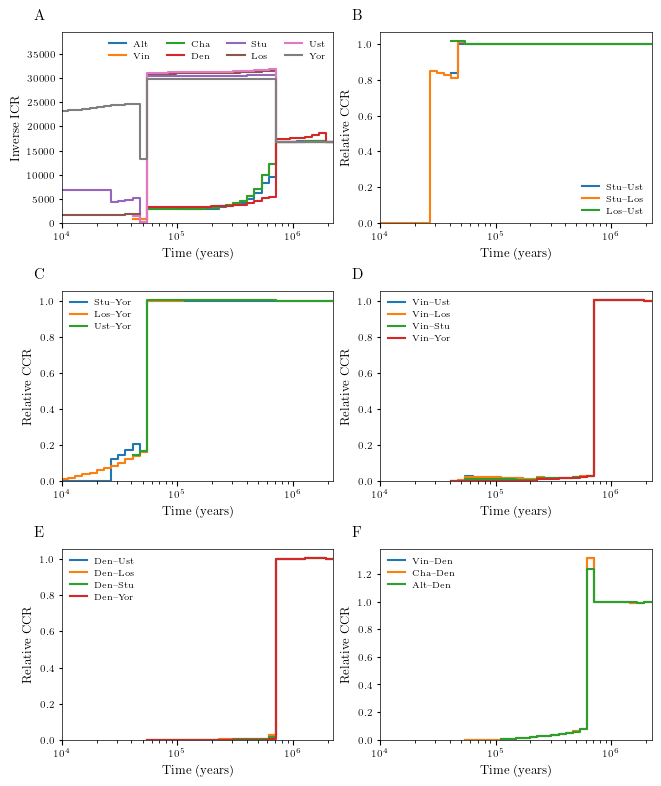

In [10]:
mosaic = "AB;CD;EF"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(6.5, 7.75), layout="constrained")

def plot_rates(ax):
    for sample in samples:
        ys = _cache[(sample, sample)]
        ax.step(ts_years, 1 / (2 * ys), label=sample[:3])

    ax.legend(framealpha=0, fontsize="x-small", ncols=4)
    ax.set_ylim(0, 3.95e4)
    ax.set_xlim(1e4, ts_years[-1])
    ax.set_xscale("log")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Inverse ICR")
    return


def plot_rccr_1(ax):

    cc = lambda x, y: _cache[(x, y)] / ((_cache[(x, x)] + _cache[(y, y)]) / 2)

    pairs = [
        ["Stuttgart", "UstIshim"],
        ["Stuttgart", "Loschbour"],
        ["Loschbour", "UstIshim"],
    ]
    for s0, s1 in pairs:
        ax.step(ts_years, cc(s0, s1), label=f"{s0[:3]}--{s1[:3]}")
    ax.legend(framealpha=0, fontsize="x-small", ncols=1)
    ax.set_xscale("log")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Relative CCR")
    ax.set_xlim(1e4, ts_years[-1])
    ax.set_ylim(0,)
    return


def plot_rccr_2(ax):

    cc = lambda x, y: _cache[(x, y)] / ((_cache[(x, x)] + _cache[(y, y)]) / 2)

    pairs = [
        ["Stuttgart", "Yoruba1"],
        ["Loschbour", "Yoruba1"],
        ["UstIshim", "Yoruba1"],
    ]
    for s0, s1 in pairs:
        ax.step(ts_years, cc(s0, s1), label=f"{s0[:3]}--{s1[:3]}")
    ax.legend(framealpha=0, fontsize="x-small", ncols=1)
    ax.set_xscale("log")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Relative CCR")
    ax.set_xlim(1e4, ts_years[-1])
    ax.set_ylim(0,)
    return


def plot_rccr_3(ax):

    cc = lambda x, y: _cache[(x, y)] / ((_cache[(x, x)] + _cache[(y, y)]) / 2)

    pairs = [
        ["Vindija", "UstIshim"],
        ["Vindija", "Loschbour"],
        ["Vindija", "Stuttgart"],
        ["Vindija", "Yoruba1"],
    ]
    for s0, s1 in pairs:
        ax.step(ts_years, cc(s0, s1), label=f"{s0[:3]}--{s1[:3]}")
    ax.legend(framealpha=0, fontsize="x-small", ncols=1)
    ax.set_xscale("log")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Relative CCR")
    ax.set_xlim(1e4, ts_years[-1])
    ax.set_ylim(0,)
    return


def plot_rccr_4(ax):

    cc = lambda x, y: _cache[(x, y)] / ((_cache[(x, x)] + _cache[(y, y)]) / 2)

    pairs = [
        ["Denisova", "UstIshim"],
        ["Denisova", "Loschbour"],
        ["Denisova", "Stuttgart"],
        ["Denisova", "Yoruba1"],
    ]
    for s0, s1 in pairs:
        ax.step(ts_years, cc(s0, s1), label=f"{s0[:3]}--{s1[:3]}")
    ax.legend(framealpha=0, fontsize="x-small", ncols=1)
    ax.set_xscale("log")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Relative CCR")
    ax.set_xlim(1e4, ts_years[-1])
    ax.set_ylim(0,)
    return


def plot_rccr_5(ax):

    cc = lambda x, y: _cache[(x, y)] / ((_cache[(x, x)] + _cache[(y, y)]) / 2)

    pairs = [
        ["Vindija", "Denisova"],
        ["Chagyrskaya", "Denisova"],
        ["Altai", "Denisova"],
    ]
    for s0, s1 in pairs:
        ax.step(ts_years, cc(s0, s1), label=f"{s0[:3]}--{s1[:3]}")
    ax.legend(framealpha=0, fontsize="x-small", ncols=1)
    ax.set_xscale("log")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Relative CCR")
    ax.set_xlim(1e4, ts_years[-1])
    ax.set_ylim(0,)
    return

for label, ax in axs.items():
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)))
    

plot_rates(axs["A"])
plot_rccr_1(axs["B"])
plot_rccr_2(axs["C"])
plot_rccr_3(axs["D"])
plot_rccr_4(axs["E"])
plot_rccr_5(axs["F"])
plt.savefig("figures/figS_expected_psmc_plot.pdf")